# 06 — Evaluation: which model is best, where, and is the difference real?
**EM 630 · Electricity Demand Forecasting · Phase 7**

A single MAE per model hides most of the story. This notebook asks:
1. **Is the ranking real?** Significance tests that respect time dependence.
2. **Where and when do models fail?** By hour, month, demand level, day type and peak hours.
3. **Is performance stable?** Month-by-month walk-forward, with retraining.
4. **What actually matters?** Feature-group ablation and SHAP.
5. **Is anything left to learn?** Residual autocorrelation.

Every number here comes from `results/tables/`, produced by `scripts/compare_all.py` and `scripts/run_phase7_experiments.py`.

In [1]:
import sys, inspect, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
from src import config, compare as cp
pd.set_option("display.precision", 3)
TD = config.TABLE_DIR
def show(name, width=1000):
    display(Image(filename=str(config.FIG_DIR / f"{name}.png"), width=width))
print("Final contenders:", cp.FINAL)

Final contenders: ['Naive-1 (persistence)', 'Naive-1 + hourly step', 'Lasso + hour×month', 'Random Forest', 'XGBoost', 'MLP v4 [64,32] Δ-target']


---
## 1. The unified table (`compare_all.csv`)
One scoring function, identical test rows for every model (enforced by a test).

In [2]:
tab = pd.read_csv(TD / "compare_all.csv")
t = tab[(tab.split == "test") & (tab.subset == "all") & tab.final_contender]
t[["model", "family", "MAE", "RMSE", "MAPE", "R2", "Bias", "skill_vs_naive1", "skill_vs_step"]].sort_values("MAE").reset_index(drop=True)

,model,family,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1,skill_vs_step
0,XGBoost,Tree,51.734,76.165,1.204,0.997,1.125,0.747,0.304
1,Random Forest,Tree,51.908,76.432,1.208,0.997,1.098,0.746,0.301
2,"MLP v4 [64,32] Δ-target",Neural,52.123,76.369,1.215,0.997,1.753,0.745,0.299
3,Lasso + hour×month,Linear,64.913,92.030,1.558,0.995,5.077,0.683,0.127
4,Naive-1 + hourly step,Baseline,74.313,104.284,1.774,0.994,2.158,0.637,0.000
5,Naive-1 (persistence),Baseline,204.685,265.201,5.055,0.959,0.424,0.000,-1.754


---
## 2. Is the ranking real?

💡 **Why ordinary tests fail here.** Forecast errors are autocorrelated: a model that is wrong at 09:00 is likely wrong at 10:00. Treating 4,762 hours as 4,762 independent observations overstates our certainty. We use two methods that respect the time dependence:

**Diebold–Mariano test.** With loss differential $d_t = |e^{(1)}_t| - |e^{(2)}_t|$, test $H_0: \mathbb{E}[d_t]=0$ using
$$DM = \frac{\bar d}{\sqrt{\widehat{\mathrm{LRV}}(d)/T}},$$
where the long-run variance uses a Newey–West (Bartlett) kernel with 24 lags, so the autocorrelation is included in the standard error. Holm's correction controls false positives across the 15 pairwise tests.

**Moving-block bootstrap.** Resample whole weeks (168-hour blocks) to get confidence intervals for MAE and for MAE differences.

In [3]:
print(inspect.getsource(cp.diebold_mariano))

def diebold_mariano(e1, e2, lags: int = 24, h: int = 1) -> dict:
    d = np.abs(np.asarray(e1)) - np.abs(np.asarray(e2))
    T = len(d)
    lrv = newey_west_var(d, lags)
    dm = d.mean() / np.sqrt(lrv / T)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    stat = dm * hln
    p = 2 * stats.t.sf(abs(stat), df=T - 1)
    return {"mean_diff": d.mean(), "dm_stat": stat, "p_value": p, "T": T, "lags": lags}



**Checking the test before trusting it.** On simulated data where two models are *equally* good but have autocorrelated errors, a correct 5% test should reject about 5% of the time:

In [4]:
from scipy import stats
rng = np.random.default_rng(0)
def ar(n, phi):
    z = rng.normal(size=n); x = np.empty(n); x[0] = z[0]
    for t_ in range(1, n): x[t_] = phi * x[t_ - 1] + z[t_]
    return x
rej_dm = rej_naive = 0; N = 200
for _ in range(N):
    c = ar(4762, 0.5) * 60
    e1, e2 = c + ar(4762, 0.5) * 20, c + ar(4762, 0.5) * 20
    rej_dm += cp.diebold_mariano(e1, e2)["p_value"] < 0.05
    d = np.abs(e1) - np.abs(e2)
    rej_naive += 2 * stats.t.sf(abs(d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))), len(d) - 1) < 0.05
print(f"False-positive rate (target 5%):  DM with Newey-West {rej_dm / N:.1%}   |   naive t-test {rej_naive / N:.1%}")

False-positive rate (target 5%):  DM with Newey-West 5.5%   |   naive t-test 14.0%


✅ The Newey–West DM test holds its 5% level; the naive test rejects true nulls more than twice as often.

In [5]:
pd.read_csv(TD / "compare_ci.csv")

,model,MAE,ci_low,ci_high
0,Naive-1 (persistence),204.685,185.251,218.365
1,Naive-1 + hourly step,74.313,70.342,78.200
2,Lasso + hour×month,64.913,61.044,68.632
3,Random Forest,51.908,48.347,55.025
4,XGBoost,51.734,48.099,54.442
5,"MLP v4 [64,32] Δ-target",52.123,48.051,55.907


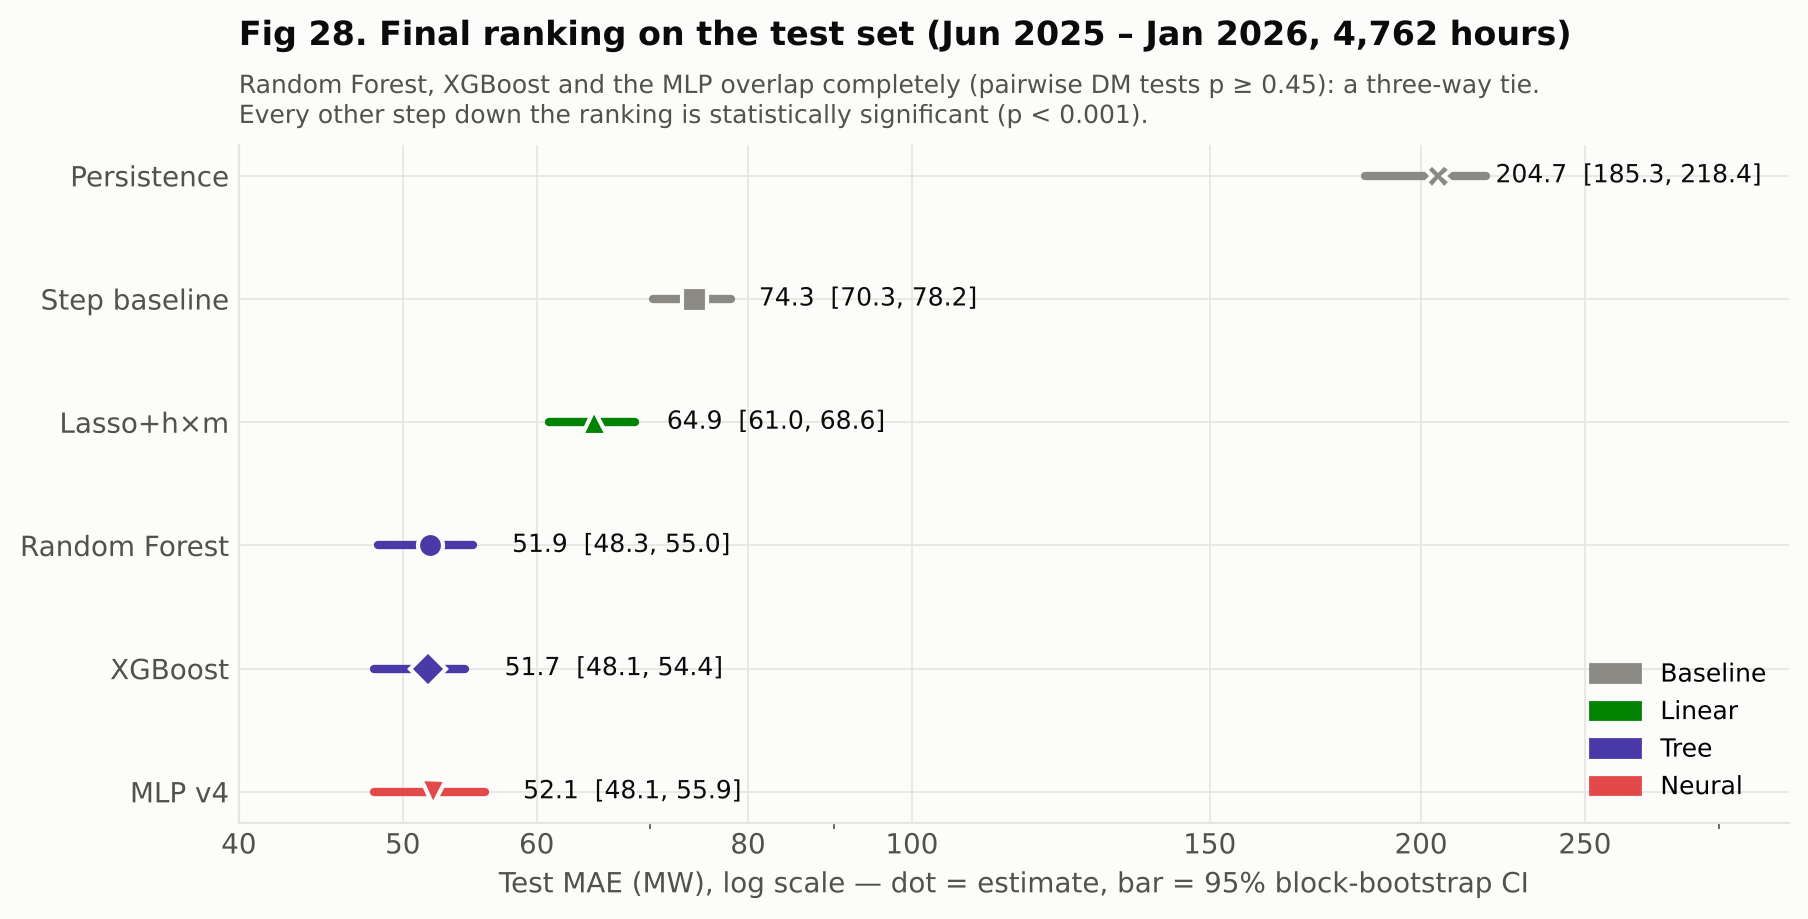

In [6]:
show("F28_final_ranking_ci")

In [7]:
dm = pd.read_csv(TD / "compare_dm.csv")
dm[["model_a", "model_b", "MAE_a_minus_b", "gap_ci_low", "gap_ci_high", "p_value", "p_holm", "significant_5pct"]]

,model_a,model_b,MAE_a_minus_b,gap_ci_low,gap_ci_high,p_value,p_holm,significant_5pct
0,Naive-1 (persistence),Naive-1 + hourly step,130.371,110.064,144.889,0.000,0.0,True
1,Naive-1 (persistence),Lasso + hour×month,139.772,120.482,153.841,0.000,0.0,True
2,Naive-1 (persistence),Random Forest,152.776,133.766,167.213,0.000,0.0,True
3,Naive-1 (persistence),XGBoost,152.950,134.130,166.918,0.000,0.0,True
4,Naive-1 (persistence),"MLP v4 [64,32] Δ-target",152.561,133.616,166.378,0.000,0.0,True
5,Naive-1 + hourly step,Lasso + hour×month,9.400,6.909,12.252,0.000,0.0,True
6,Naive-1 + hourly step,Random Forest,22.405,19.750,26.025,0.000,0.0,True
7,Naive-1 + hourly step,XGBoost,22.579,20.188,26.223,0.000,0.0,True
8,Naive-1 + hourly step,"MLP v4 [64,32] Δ-target",22.190,19.432,25.825,0.000,0.0,True
9,Lasso + hour×month,Random Forest,13.005,11.131,15.163,0.000,0.0,True


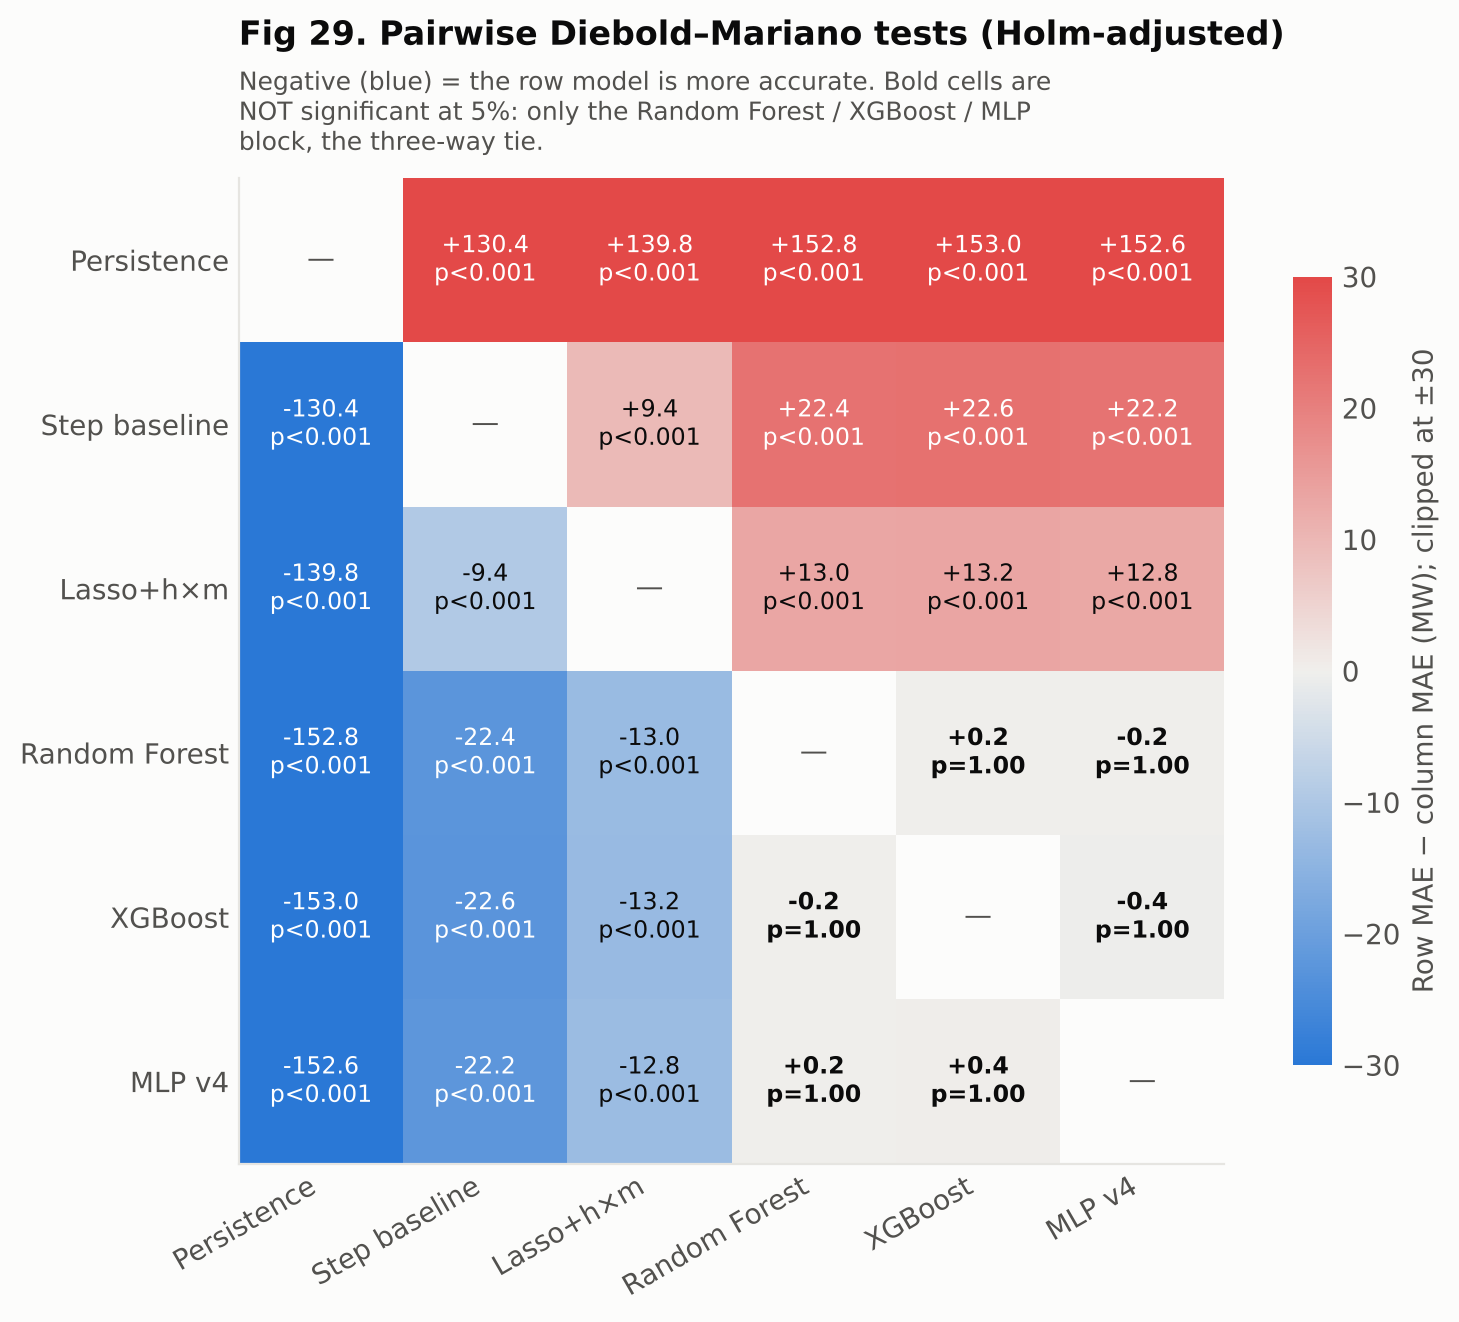

In [8]:
show("F29_dm_matrix", 850)

✅ **Finding: a three-way tie.** Random Forest (51.9), XGBoost (51.7) and MLP v4 (52.1) are **statistically indistinguishable**: Holm-adjusted p = 1.0, and every bootstrap CI of their pairwise gaps contains 0. Every other step down the ranking is significant (p < 0.001): nonlinear > Lasso + h×m > step baseline > persistence.
The report must therefore say *"three models tie for best"*, not *"XGBoost wins"*.

---
## 3. Where and when do models fail?

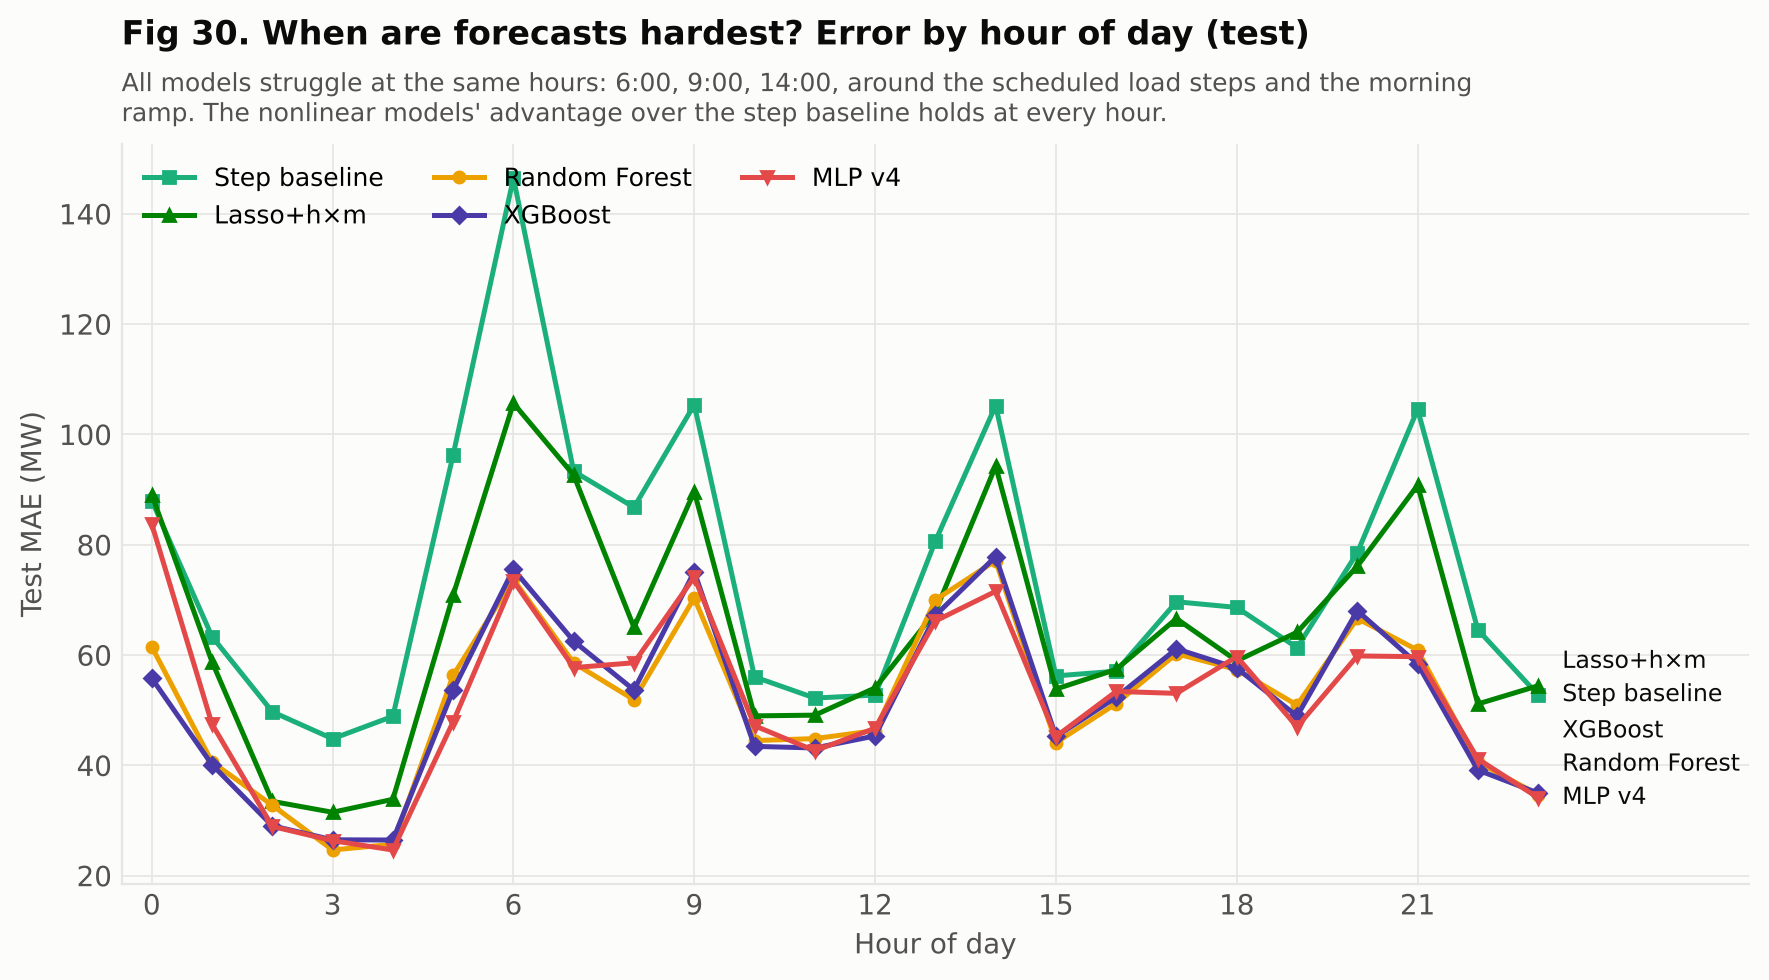

In [9]:
show("F30_error_by_hour")

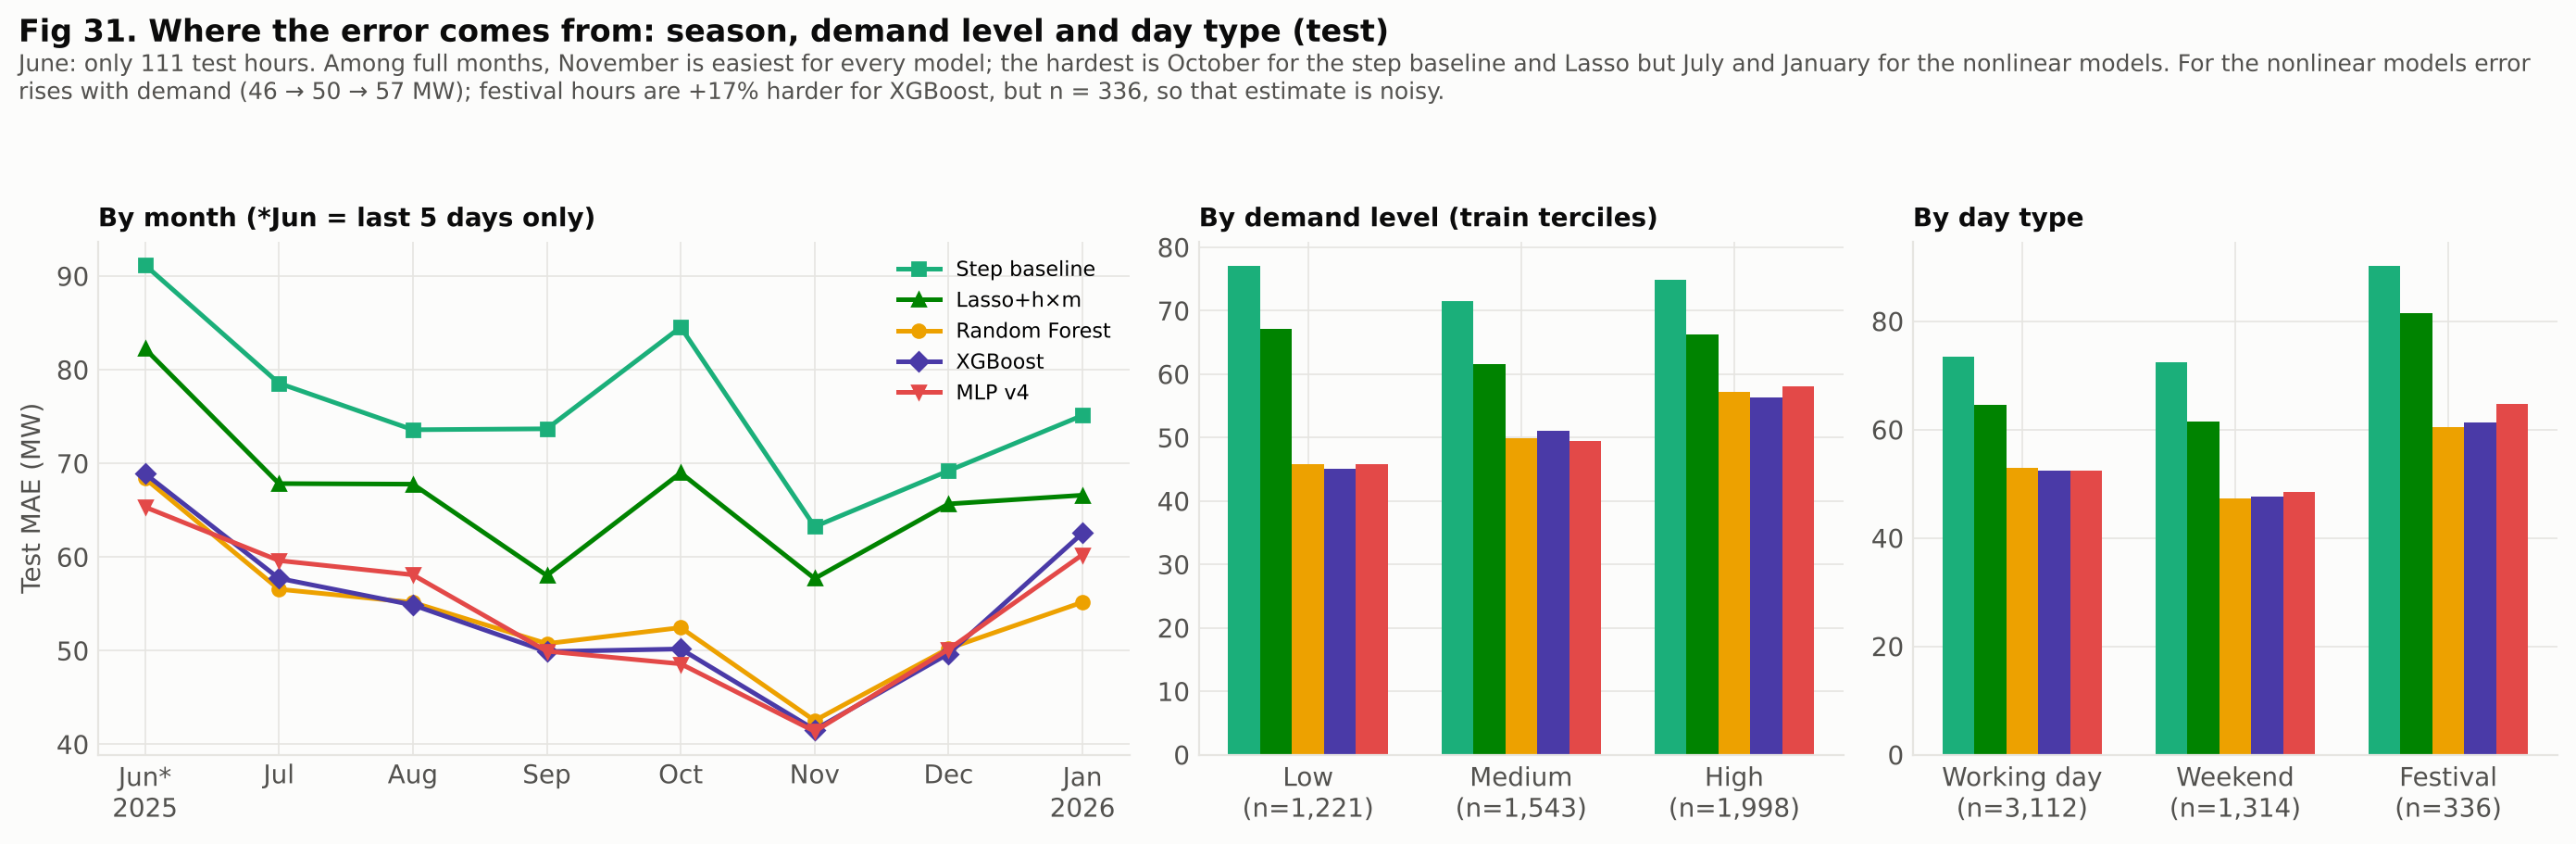

,Naive-1 (persistence),Naive-1 + hourly step,Lasso + hour×month,Random Forest,XGBoost,"MLP v4 [64,32] Δ-target",n
2025-06,228.8,91.2,82.2,68.4,68.9,65.3,111
2025-07,208.1,78.6,67.8,56.6,57.7,59.6,728
2025-08,176.6,73.6,67.8,55.1,54.9,58.1,744
2025-09,181.5,73.7,58.0,50.7,49.9,49.9,720
2025-10,151.1,84.5,69.0,52.4,50.2,48.6,744
2025-11,200.9,63.2,57.7,42.5,41.6,41.4,720
2025-12,263.0,69.2,65.7,50.2,49.7,50.1,739
2026-01,329.3,75.1,66.6,55.2,62.5,60.2,256


In [10]:
show("F31_error_breakdowns", 1100)
display(pd.read_csv(TD / "breakdown_month.csv", index_col=0).round(1))

✅ **Findings**
- **By hour:** all models are worst at the same hours (06:00, 09:00, 14:00), around the scheduled load steps and the morning ramp. The nonlinear models beat the step baseline at every hour.
- **By month:** November is easiest for every model. June has only 5 test days, so its value is unreliable.
- **By demand level:** for the nonlinear models, error rises with load (46 → 50 → 57 MW).
- **Festival days** are harder (+17% for XGBoost), but with only 336 test hours this is a noisy estimate. That matches the EDA expectation that the largest errors would come on festival days.

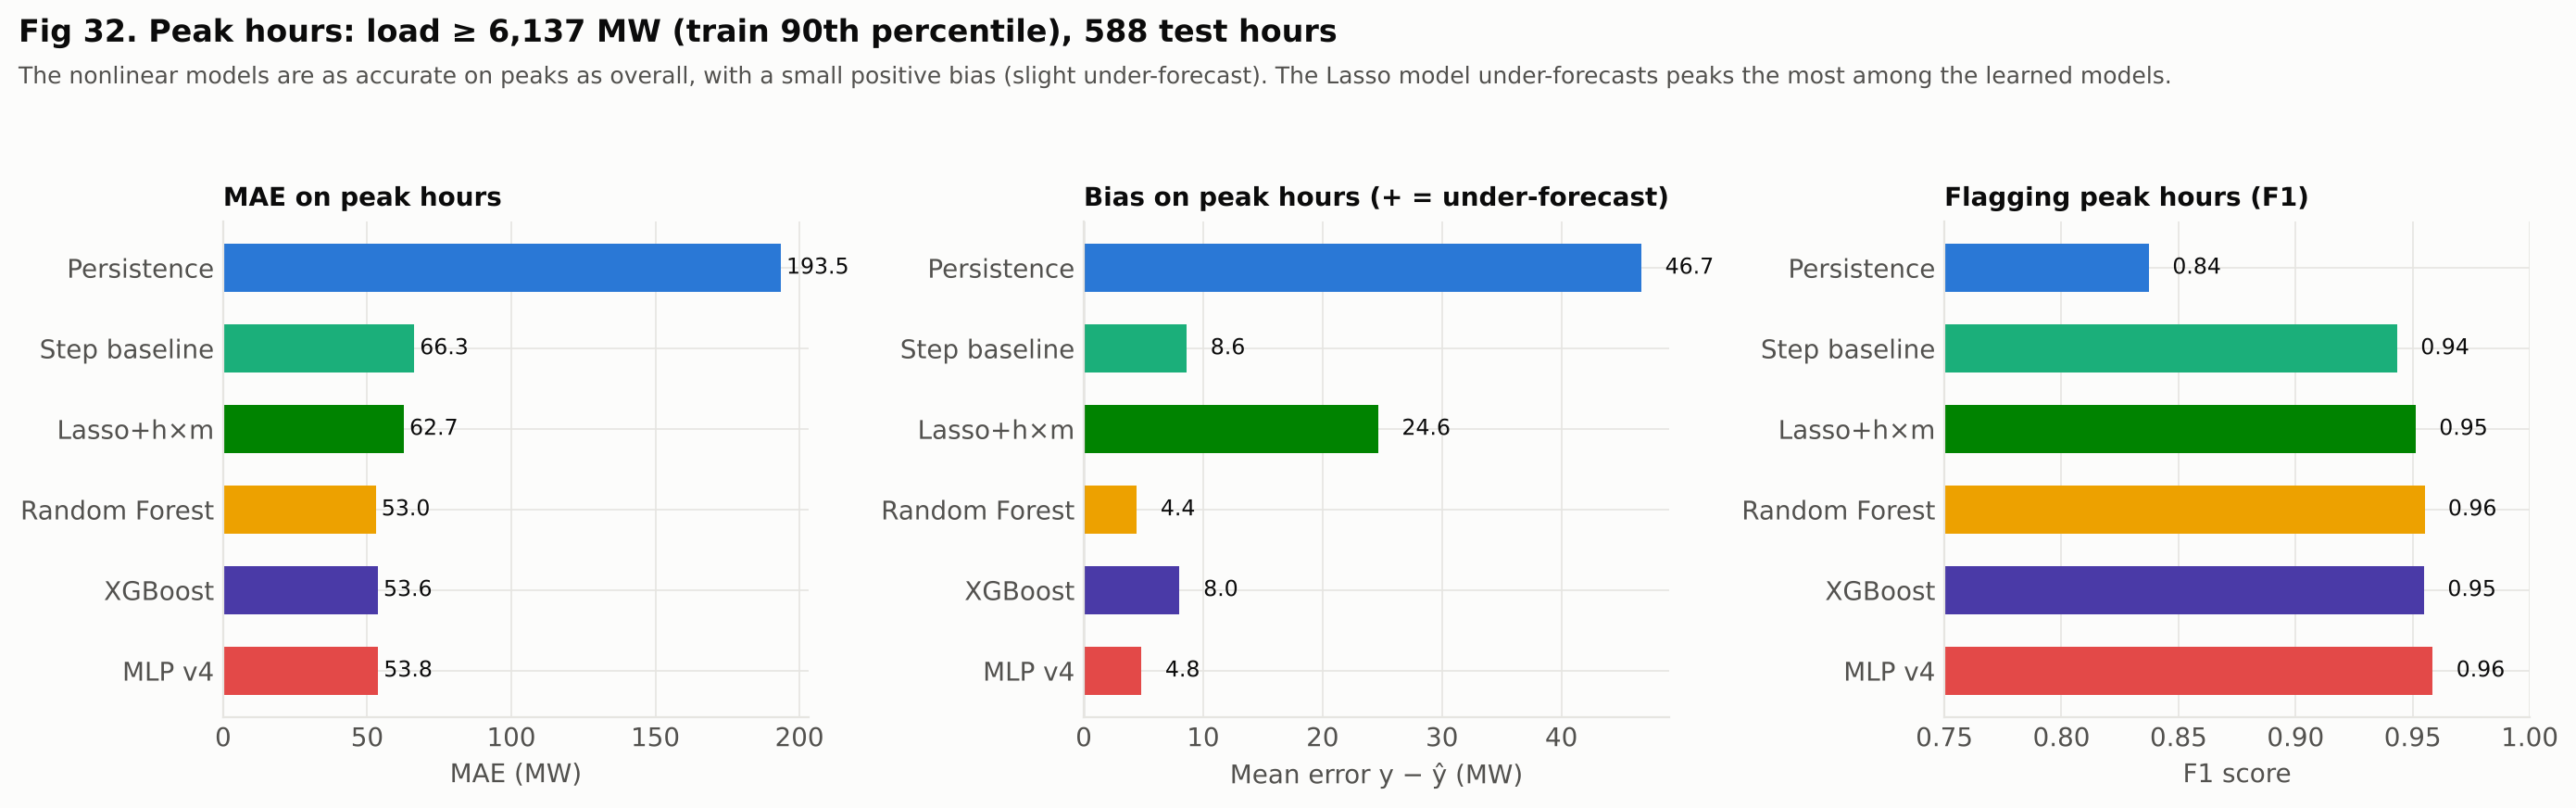

,model,TP,FP,FN,TN,precision,recall,F1
0,Naive-1 (persistence),492,95,96,4079,0.838,0.837,0.837
1,Naive-1 + hourly step,558,37,30,4137,0.938,0.949,0.943
2,Lasso + hour×month,557,26,31,4148,0.955,0.947,0.951
3,Random Forest,564,29,24,4145,0.951,0.959,0.955
4,XGBoost,561,26,27,4148,0.956,0.954,0.955
5,"MLP v4 [64,32] Δ-target",568,29,20,4145,0.951,0.966,0.959


In [11]:
show("F32_peak_hours", 1100)
pd.read_csv(TD / "peak_classification.csv")

✅ **Peak hours** (≥ 6,137 MW, train 90th percentile, 588 test hours): the nonlinear models are as accurate on peaks as overall (≈ 53–54 MW) with only a small under-forecast (4–8 MW), and they flag peak hours with F1 ≈ 0.96. Lasso under-forecasts peaks the most among the learned models (+24.6 MW). For a utility, under-forecasting peaks is the costly direction, so this matters more than the overall MAE suggests.

---
## 4. Walk-forward: stability and retraining

For each test month, every model is refit on **all data before that month** with its fixed Phase 4–6 hyperparameters, then scored on the month. This mimics a utility retraining its model monthly.

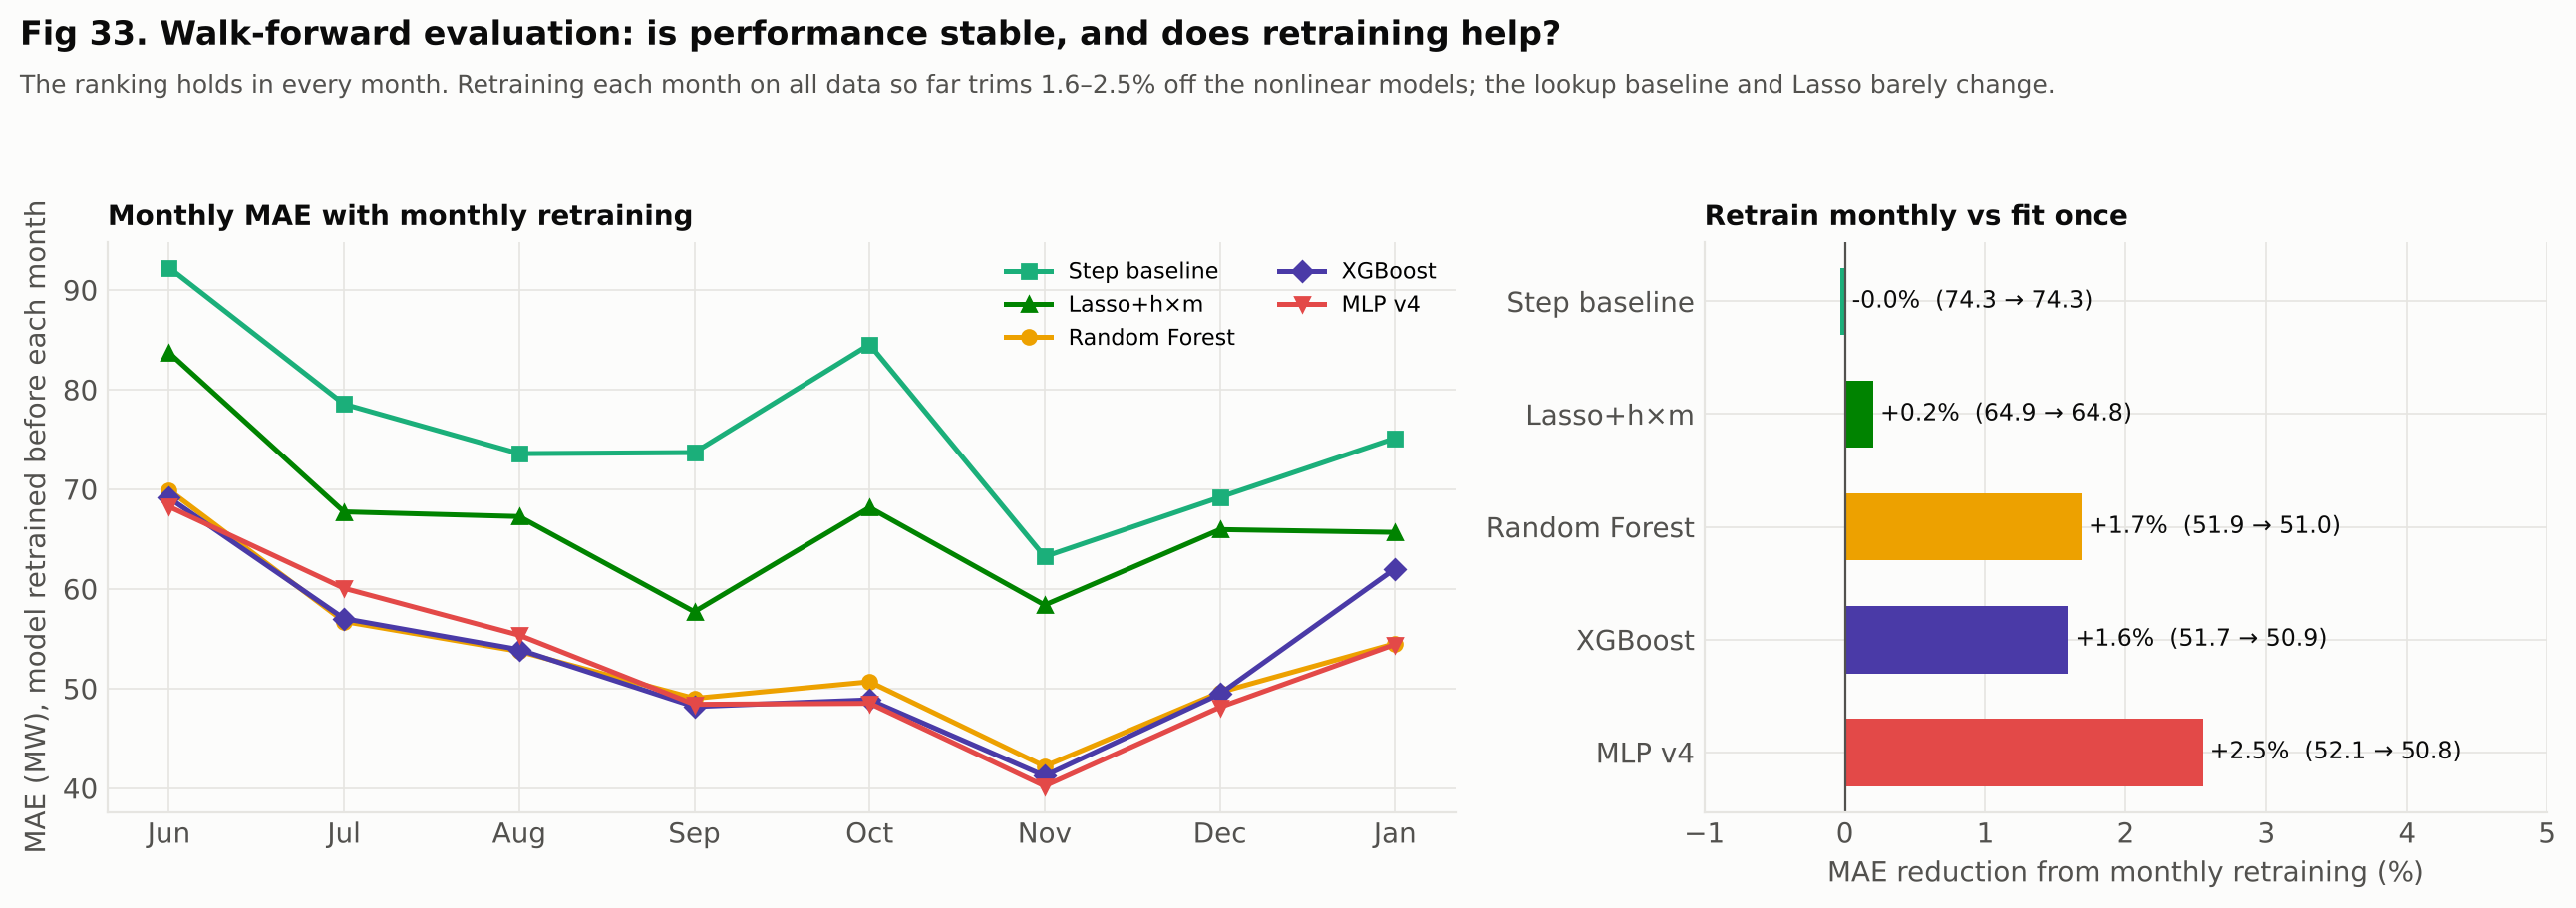

model,Lasso + hour×month,"MLP v4 [64,32] Δ-target",Naive-1 + hourly step,Random Forest,XGBoost
month,,,,,
2025-06,83.7,68.3,92.2,69.9,69.1
2025-07,67.7,60.1,78.5,56.7,57.0
2025-08,67.3,55.4,73.6,53.7,53.9
2025-09,57.7,48.4,73.7,49.0,48.2
2025-10,68.2,48.5,84.5,50.7,48.9
2025-11,58.4,40.2,63.2,42.2,41.2
2025-12,66.0,48.1,69.2,49.6,49.5
2026-01,65.7,54.4,75.1,54.5,62.0


In [12]:
show("F33_walkforward", 1100)
wf = pd.read_csv(TD / "phase7_walkforward.csv")
wf.pivot(index="month", columns="model", values="MAE_walkforward").round(1)

✅ The ranking holds in every month. **Monthly retraining trims 1.6–2.5%** off the nonlinear models (XGBoost 51.7 → 50.9 MW), a cheap, practical improvement for deployment. The lookup baseline and Lasso barely change.

---
## 5. What actually matters: feature-group ablation

XGBoost (Δ-target, fixed hyperparameters, mean of 3 seeds) is refit with feature groups added one at a time. DM tests check whether each change is real.

In [13]:
display(pd.read_csv(TD / "phase7_ablation.csv").round(2))
pd.read_csv(TD / "phase7_ablation_dm.csv")

,feature_set,split,n_features,MAE_ensemble,MAE_seed_mean,MAE_seed_std
0,A_load_calendar,val,21,58.84,58.96,0.10
1,A_load_calendar,test,21,51.50,51.61,0.06
2,B_+weather,val,27,59.13,59.25,0.03
3,B_+weather,test,27,51.76,51.88,0.15
4,C_+festival,val,28,59.21,59.32,0.13
5,C_+festival,test,28,51.50,51.62,0.10
6,D_+weather_at_h (what-if),val,33,59.29,59.40,0.05
7,D_+weather_at_h (what-if),test,33,51.84,51.97,0.17


,from,to,MAE_change,p_value
0,A_load_calendar,B_+weather,0.265,3.009e-02
1,B_+weather,C_+festival,-0.259,3.500e-04
2,C_+festival,D_+weather_at_h (what-if),0.342,1.600e-04


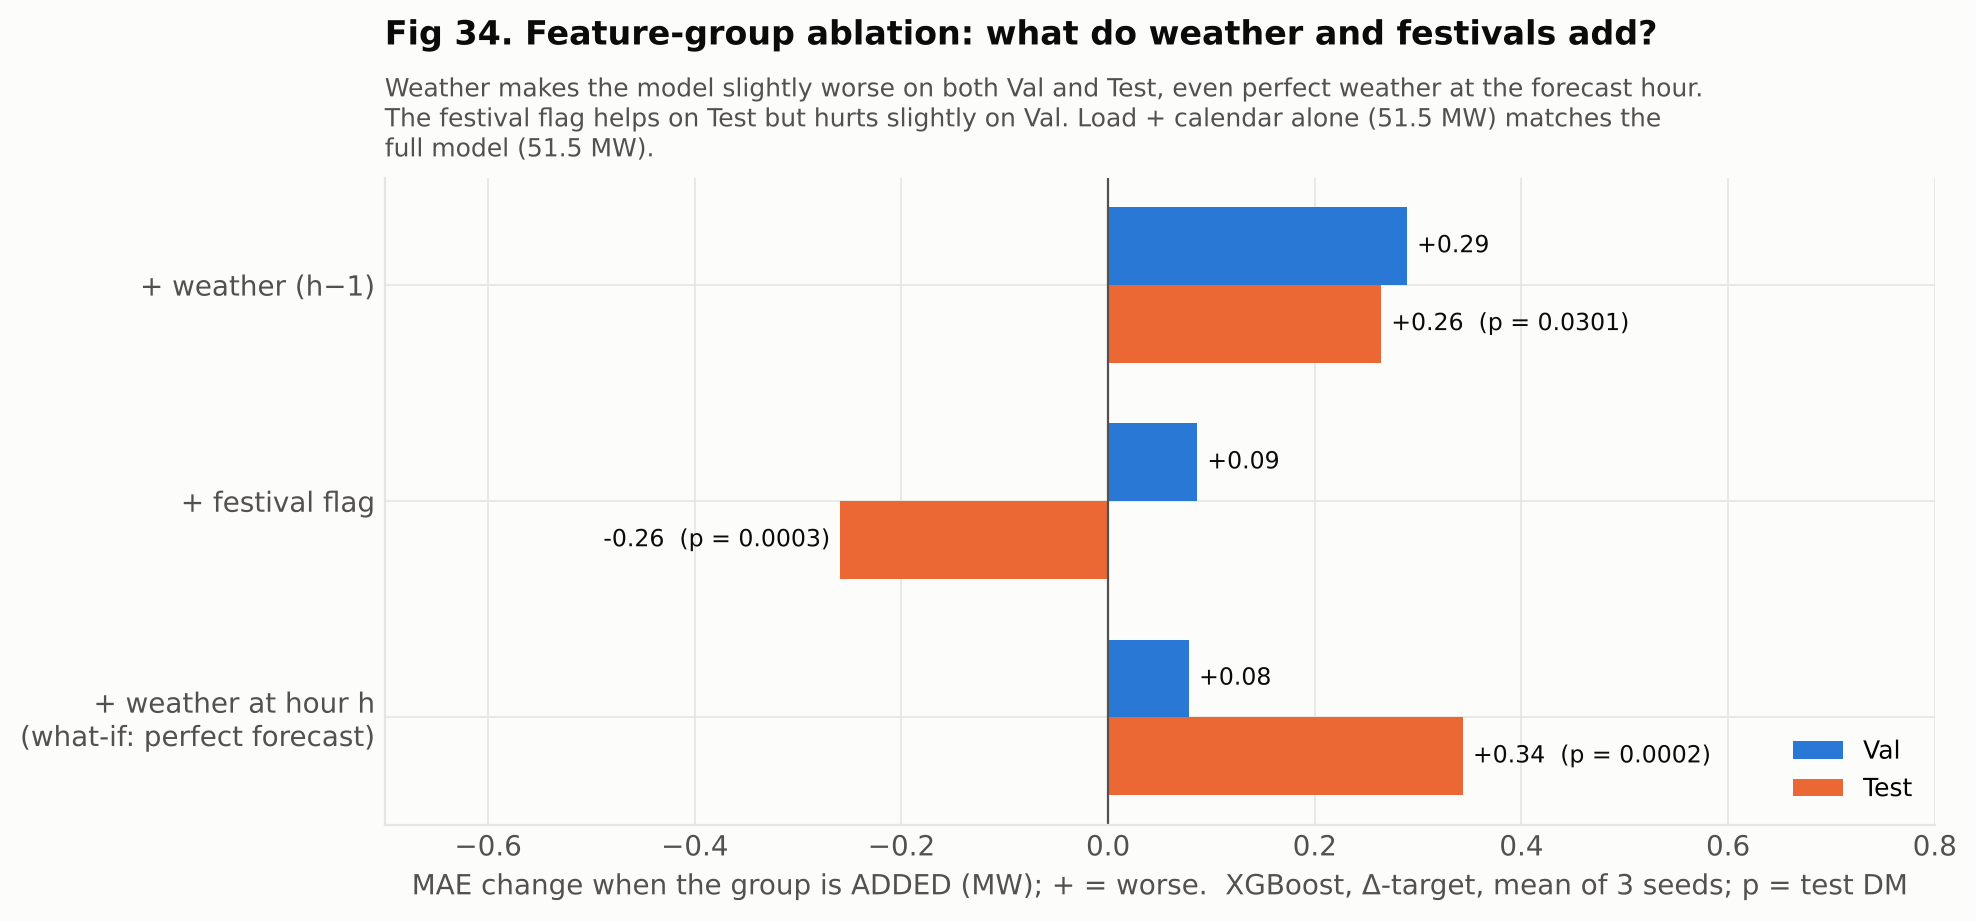

In [14]:
show("F34_ablation")

✅ **Findings**
- **Weather makes the model slightly worse**, on both Val (+0.29) and Test (+0.26, p = 0.03). Even *perfect* weather at the forecast hour, information no real forecaster has, does not help. This is the strongest confirmation of the EDA finding (Fig 5) that the weather columns carry no signal beyond the calendar.
- **Festival flag:** helps on Test (−0.26, p < 0.001) but not on Val (+0.09). Its value is uncertain, plausibly because the Val period (Mar–Jun) has few festivals.
- **Load + calendar alone (51.5 MW) matches the full model.**

⚠️ **Not acted on here, on purpose.** Switching the final model to "no weather" now would be a decision informed by the test set. It is recorded in `FEATURES.md` as a recommendation, to be confirmed by cross-validation in future work.

---
## 6. Why does XGBoost predict what it does? (SHAP)

**SHAP values** split each prediction into additive contributions from each feature:
$$\hat d_h = \phi_0 + \sum_j \phi_j(x_h),$$
where $\hat d_h$ is the predicted **hourly change** (the Δ-target). The additivity check below confirms the decomposition is exact.

In [15]:
sv = pd.read_csv(TD / "phase7_shap_values.csv", index_col=0)
pd.read_csv(TD / "phase7_shap_importance.csv", index_col=0).head(12).T

,load_ramp_1,hour,hour_sin,hour_cos,load_lag_3,load_lag_2,load_roll_mean_24,load_lag_1,load_lag_24,temp_roll_mean_24,load_roll_mean_168,load_lag_48
mean_abs_shap_MW,74.725,40.773,29.892,27.03,23.866,20.559,15.456,11.55,11.41,7.33,6.701,6.121


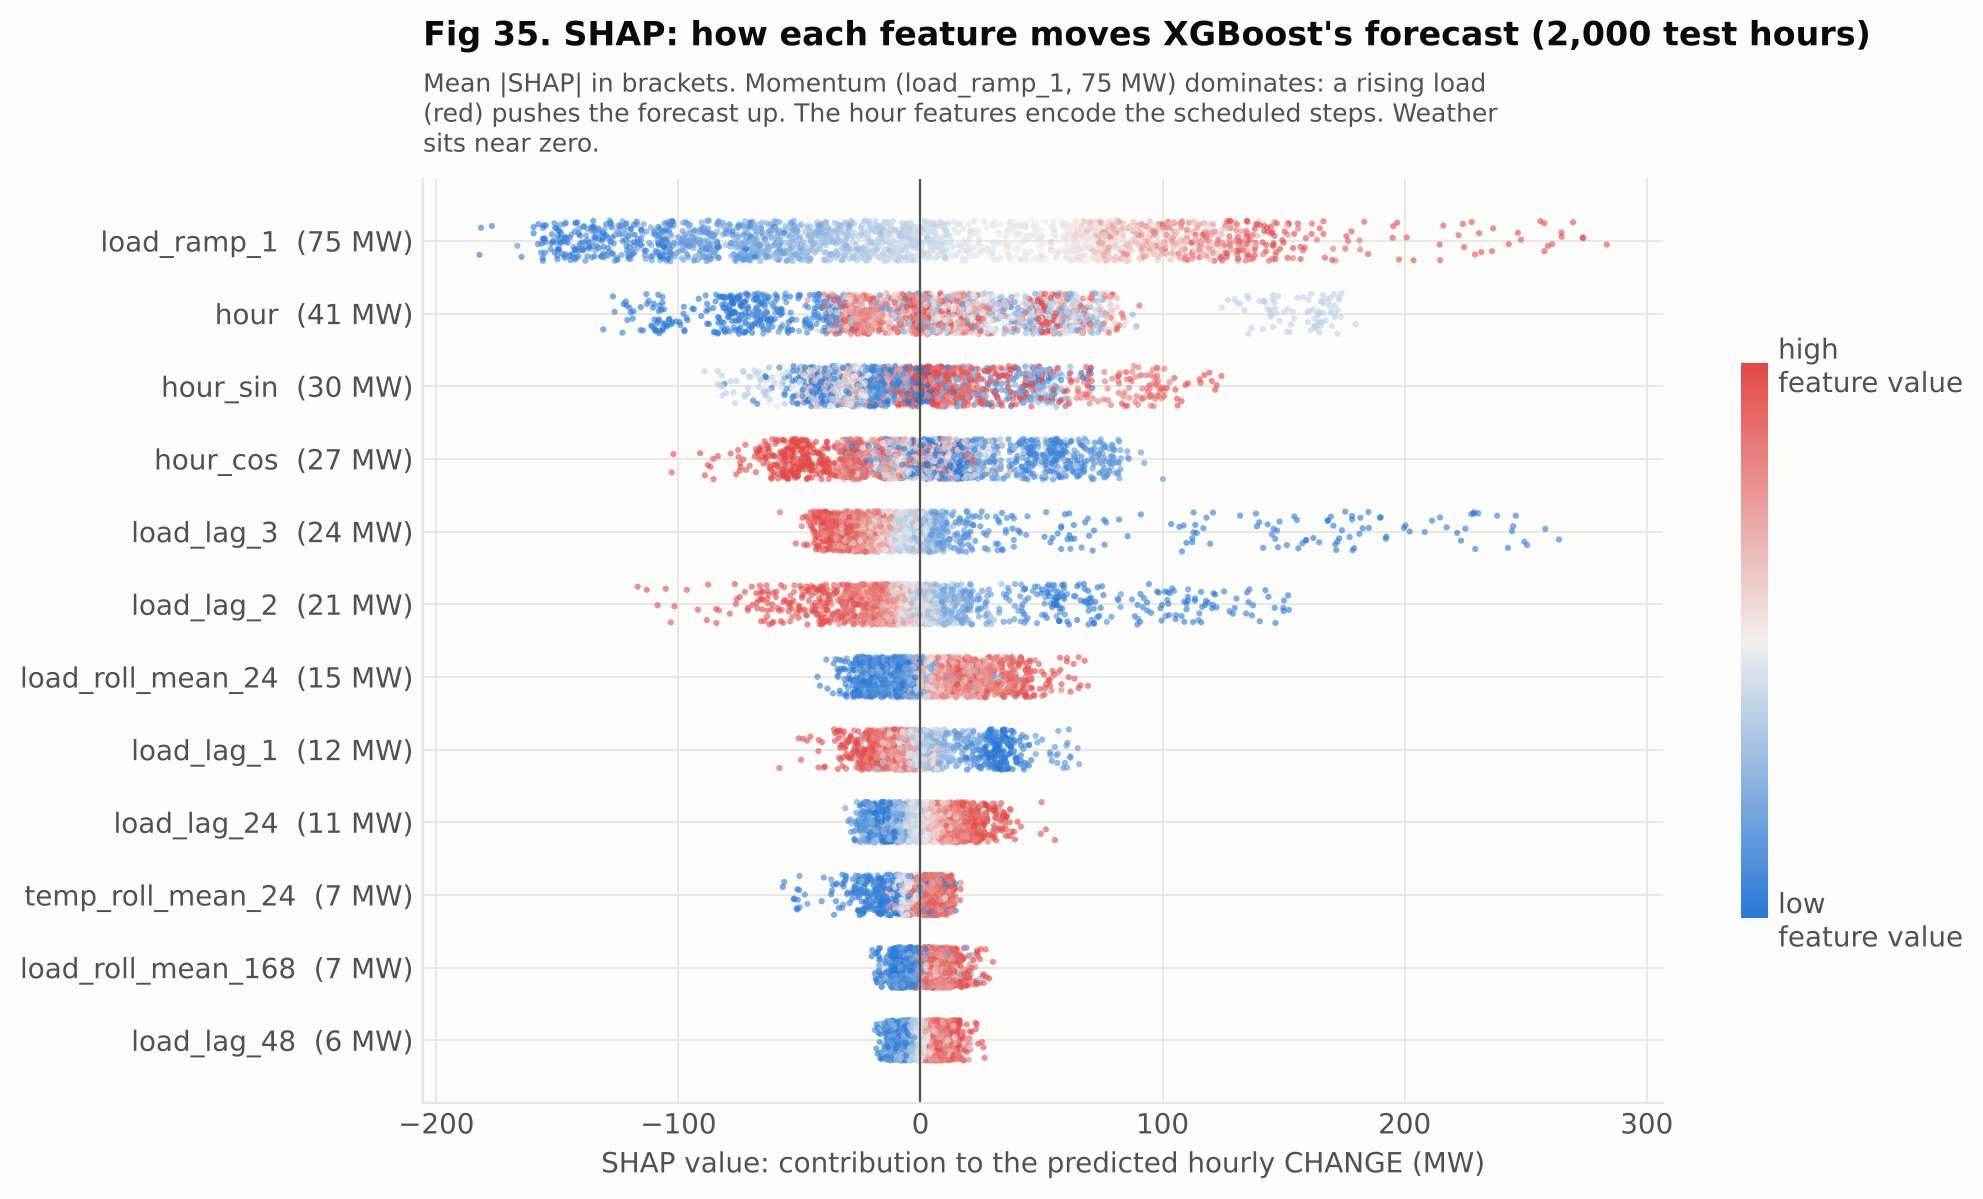

In [16]:
show("F35_shap_summary", 950)

✅ **Reading the SHAP plot**
- **Momentum dominates:** a rising load in the last hour (high `load_ramp_1`, red) pushes the predicted change up, and a falling load pushes it down.
- **Hour features** carry the scheduled steps from Phase 3 (the 09:00 jump and the night drops).
- **`load_lag_3`: high values push the forecast down**, a mean-reversion effect: if load was high three hours ago, the current rise is likely to fade.
- Weather (`temp_roll_mean_24`) contributes about 7 MW on average, mostly acting as a seasonal proxy.

---
## 7. Is anything left to learn?

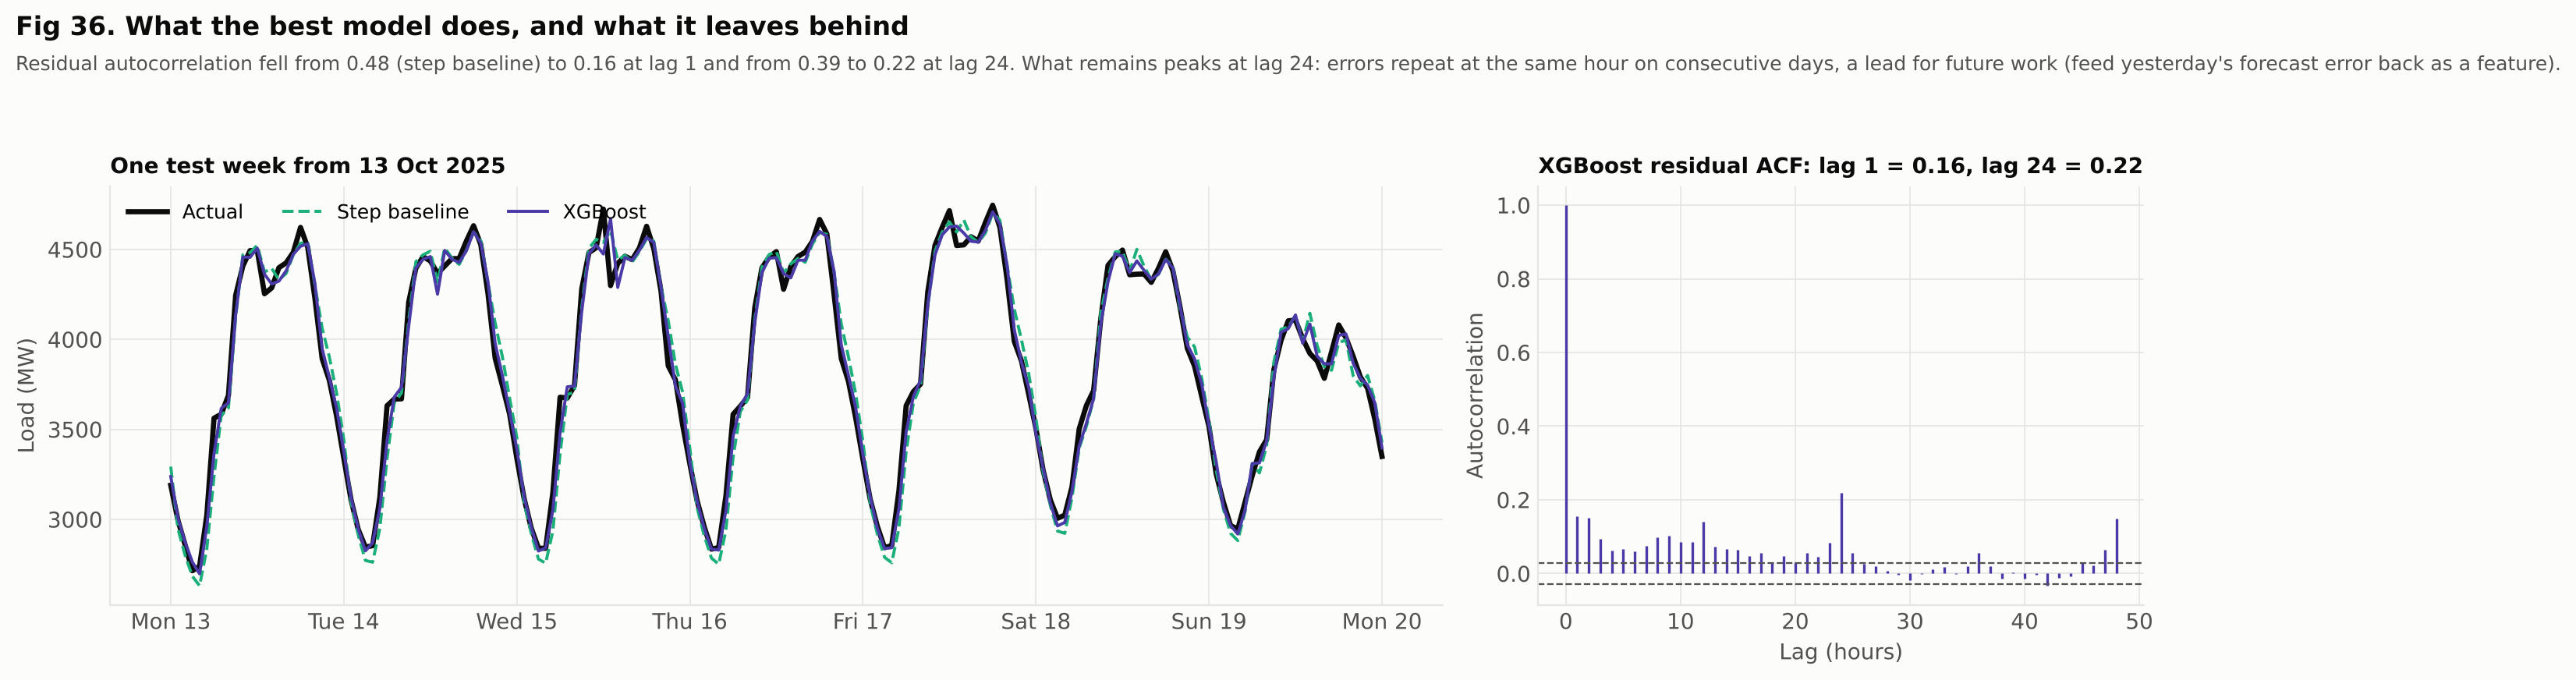

In [17]:
show("F36_week_and_residual_acf", 1100)

✅ Compared with the step baseline, the best model removes most of the autocorrelation in the errors (lag 1: 0.48 → 0.16). What remains peaks at **lag 24 (0.22)**: a model that errs at 09:00 today tends to err at 09:00 tomorrow. That is a concrete lead for future work, such as feeding yesterday's forecast error at the same hour back in as a feature.

---
## 8. Summary for the report

| Question | Answer |
|---|---|
| Best model? | **Three-way tie**: Random Forest 51.9, XGBoost 51.7, MLP v4 52.1 MW (MAPE ≈ 1.2%); differences not significant |
| Improvement over baselines | 30% vs the step baseline (74.3), 75% vs persistence (204.7); all p < 0.001 |
| Improvement over best linear model | 20% (64.9 → ≈ 52); p < 0.001 |
| Hardest conditions | Scheduled-step hours (06, 09, 14 h), high-demand hours, festival days |
| Peaks | Accurate (≈ 53 MW) with small under-forecast; F1 ≈ 0.96 for flagging peaks |
| Monthly retraining | Helps the nonlinear models by 1.6–2.5% |
| Weather features | Slightly harmful, even "perfect" weather; data limitation |
| Remaining structure | Errors repeat at the same hour on consecutive days (lag-24 ACF 0.22) |